# 11 · Fairness and ethics (Step 13)

**Goal:** check whether the model treats groups of applicants differently, understand why, and
test three ways to narrow the gap.

- **A. Audit** by gender and age band: approval rates, good customers wrongly declined, defaulters
  declined, calibration, and the Step 11 approve / refer / decline layer per group.
- **B. Proxy test:** gender is not a model input. Can the other 240 features recover it?
- **C. Impossibility demo:** with the real base rates (men default more often than women), no
  decision rule can have equal error rates and equal precision for both groups.
- **D. Three mitigations for gender:** reweighing (before training), Fairlearn's
  `ExponentiatedGradient` (during training) and one threshold per group (after training).
  Profit against the fairness gap for each.

**Setup:** "declined" means not approved by the Step 10 money rule (approve if p < 0.1667).
The main fairness measure is **equal opportunity** (Hardt et al. 2016): good customers should be
wrongly declined at the same rate in every group. These are the people a wrong rejection harms.

**Data rules:** the model and the retrained variants learn from the train split only; everything
is measured on the validation split. The per-group thresholds are chosen on validation, so they
are cross-fitted (chosen on 4/5, scored on the other 1/5). The test split stays locked until
Step 15.

**Time:** about 10 minutes (ExponentiatedGradient fits about 40 LightGBM models).

**Saved results:**

- `reports/results_step13_audit.csv`, `reports/results_step13_mitigation.csv`
- `reports/figures/fig30_fairness_audit.png`, `fig31_group_calibration.png`,
  `fig32_fairness_tradeoff.png`
- `models/reweighed_final.joblib` (the reweighed model, for Step 15)

In [1]:
%load_ext autoreload
%autoreload 2

import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fairlearn.reductions import ErrorRate, ExponentiatedGradient, FalsePositiveRateParity
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.decision.conformal import coverage, decide
from creditrisk.decision.threshold import realised_profit
from creditrisk.fairness.audit import age_band, audit, gaps
from creditrisk.fairness.mitigate import group_thresholds, reweighing_weights
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

final_model, details = load_final_model()
model = joblib.load(MODEL_DIR / "calibrated_final.joblib")   # Step 10's choice (the raw model)
decision = json.loads((MODEL_DIR / "decision.json").read_text())
MARGIN, LGD, THRESHOLD = decision["margin"], decision["lgd"], decision["threshold"]
cuts = decision["conformal"]
cols = details["features"]                                  # gender is not among them

features = load_features()
splits = load_splits()
X_tr, y_tr, _, _ = get_xy(features, splits, "train", include_sensitive=True)
X_val, y_val, _, _ = get_xy(features, splits, "valid", include_sensitive=True)
gender_tr = X_tr["APP_CODE_GENDER"].astype(str).to_numpy()
gender = X_val["APP_CODE_GENDER"].astype(str).to_numpy()   # F / M, for the audit only
age = age_band(X_val["APP_AGE_YEARS"])
amount = X_val["APP_AMT_CREDIT"].to_numpy(dtype=float)
p_val = model.predict_proba(X_val[cols])[:, 1]
approved = p_val < THRESHOLD
print(f"validation: {len(y_val):,} applicants | women {np.mean(gender == 'F'):.1%} | "
      f"threshold {THRESHOLD:.4f} | conformal: approve below {cuts['approve_below']:.4f}, "
      f"decline above {cuts['decline_above']:.4f}")

validation: 30,751 applicants | women 66.1% | threshold 0.1667 | conformal: approve below 0.0355, decline above 0.1655


## A. Audit by gender and age band

Age bands: <30, 30–45, 45–60, 60+. "Mean predicted" vs "default rate" is calibration in the large
(Step 10 found the model calibrated overall). The gaps are between the best and worst group;
the disparate impact ratio is lowest approval rate ÷ highest (the US "80% rule" flags < 0.8).

attribute                         gender               age band              \
group                                  F           M        <30       30-45   
applicants                    20314.0000  10437.0000  4475.0000  12336.0000   
default rate                      0.0687      0.1041     0.1169      0.0917   
mean predicted                    0.0736      0.0934     0.1148      0.0886   
ROC-AUC                           0.7926      0.7838     0.7654      0.7966   
approval rate                     0.8936      0.8370     0.7781      0.8517   
good customers declined           0.0833      0.1263     0.1802      0.1149   
defaulters declined               0.4191      0.4788     0.5373      0.4801   
share approve                     0.4343      0.3402     0.2273      0.3645   
share refer                       0.4581      0.4958     0.5486      0.4858   
share decline                     0.1076      0.1639     0.2241      0.1497   
coverage repay                    0.9157      0.8728     0.8181      0.8838   
coverage default                  0.8918      0.9263     0.9598      0.9240   
defaulters auto-approved          0.1082      0.0737     0.0402      0.0760   
good customers auto-declined      0.0843      0.1272     0.1819      0.1162   

attribute                                            
group                              45-60        60+  
applicants                    10334.0000  3606.0000  
default rate                      0.0645     0.0446  
mean predicted                    0.0668     0.0473  
ROC-AUC                           0.7877     0.7383  
approval rate                     0.9123     0.9631  
good customers declined           0.0674     0.0308  
defaulters declined               0.3808     0.1677  
share approve                     0.4650     0.5699  
share refer                       0.4468     0.3927  
share decline                     0.0883     0.0374  
coverage repay                    0.9322     0.9687  
coverage default                  0.8696     0.7702  
defaulters auto-approved          0.1304     0.2298  
good customers auto-declined      0.0678     0.0313

,gender,age band
demographic parity difference,0.0566,0.1850
equal opportunity gap,0.0430,0.1494
equalized odds difference,0.0598,0.3696
disparate impact ratio,0.9367,0.8079


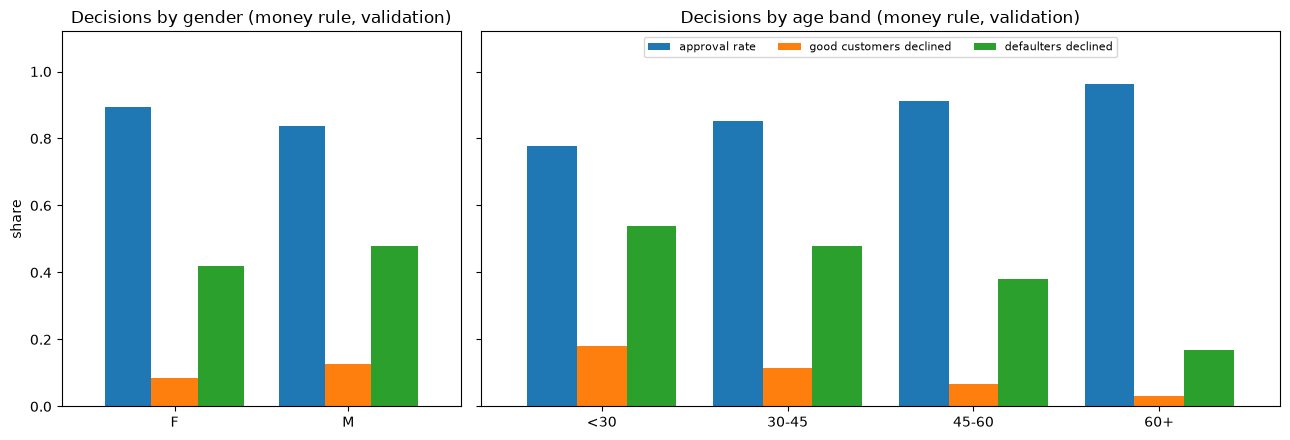

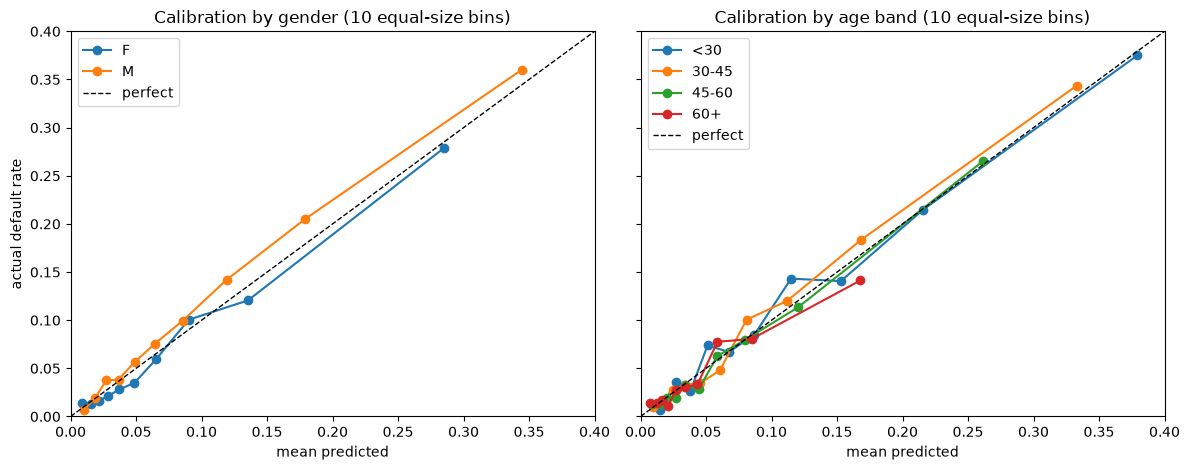

In [2]:
groups = {"gender": gender, "age band": age}
tables = {attr: audit(y_val, p_val, g, approved) for attr, g in groups.items()}

d = decide(p_val, cuts["q_repay"], cuts["q_default"])
conformal_rows = {}
for attr, g in groups.items():
    g = np.asarray(g)
    for name in tables[attr].index:
        m = g == name
        cov = coverage(p_val[m], y_val[m], cuts["q_repay"], cuts["q_default"])
        conformal_rows[(attr, name)] = {
            **{f"share {k}": np.mean(d[m] == k) for k in ("approve", "refer", "decline")},
            "coverage repay": cov["repay"], "coverage default": cov["default"],
            "defaulters auto-approved": np.mean(d[m & (y_val == 1)] == "approve"),
            "good customers auto-declined": np.mean(d[m & (y_val == 0)] == "decline")}
audit_all = pd.concat(tables, names=["attribute", "group"]).join(
    pd.DataFrame(conformal_rows).T.rename_axis(["attribute", "group"]))
display(audit_all.astype(float).round(4).T)
gap_table = pd.DataFrame({attr: gaps(t) for attr, t in tables.items()}).round(4)
display(gap_table)
audit_all.to_csv(REPORTS / "results_step13_audit.csv")
facts["audit"] = audit_all.astype(float).round(4).to_dict(orient="index")
facts["gaps"] = gap_table.to_dict()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True,
                         gridspec_kw={"width_ratios": [2, 4]})
rates = ["approval rate", "good customers declined", "defaulters declined"]
for ax, (attr, t) in zip(axes, tables.items(), strict=True):
    t[rates].plot.bar(ax=ax, rot=0, width=0.8)
    ax.set(title=f"Decisions by {attr} (money rule, validation)", xlabel="", ylim=(0, 1.12))
    ax.legend(fontsize=8, ncol=3, loc="upper center")
axes[0].get_legend().remove()                  # one legend is enough; the left panel is narrow
axes[0].set_ylabel("share")
fig.tight_layout()
fig.savefig(FIG / "fig30_fairness_audit.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for ax, (attr, g) in zip(axes, groups.items(), strict=True):
    g = np.asarray(g)
    for name in tables[attr].index:
        frac, mean_p = calibration_curve(y_val[g == name], p_val[g == name], n_bins=10,
                                         strategy="quantile")
        ax.plot(mean_p, frac, marker="o", label=name)
    ax.plot([0, 0.4], [0, 0.4], "k--", lw=1, label="perfect")
    ax.set(title=f"Calibration by {attr} (10 equal-size bins)", xlabel="mean predicted",
           xlim=(0, 0.4), ylim=(0, 0.4))
    ax.legend()
axes[0].set_ylabel("actual default rate")
fig.tight_layout()
fig.savefig(FIG / "fig31_group_calibration.png", dpi=150)
plt.show()

## B. Proxy test

"Fairness through unawareness" (leaving gender out) only works if the other features do not
carry it. A LightGBM with the final model's settings (300 trees, learning rate 0.1) learns to
predict gender from the 240 model inputs on the train split, scored on validation.

In [3]:
light = clone(final_model).set_params(n_estimators=300, learning_rate=0.1)
proxy = clone(light).fit(X_tr[cols], gender_tr == "M")
auc_proxy = roc_auc_score(gender == "M", proxy.predict_proba(X_val[cols])[:, 1])
auc_score = roc_auc_score(gender == "M", p_val)
gain = pd.Series(proxy.booster_.feature_importance("gain"), index=cols)
top_proxies = (gain / gain.sum()).nlargest(10).round(3)
print(f"gender from the 240 features: ROC-AUC {auc_proxy:.3f}")
print(f"gender from the risk score alone: ROC-AUC {auc_score:.3f}")
display(top_proxies.to_frame("share of gain"))
facts["proxy"] = {"auc_from_features": round(auc_proxy, 4), "auc_from_score": round(auc_score, 4),
                  "top": top_proxies.to_dict()}

gender from the 240 features: ROC-AUC 0.911
gender from the risk score alone: ROC-AUC 0.568


,share of gain
APP_OCCUPATION_TYPE,0.288
APP_ORGANIZATION_TYPE,0.124
APP_OWN_CAR_AGE,0.092
APP_FLAG_OWN_CAR,0.066
APP_EXT_SOURCE_1,0.052
APP_FLAG_DOCUMENT_8,0.038
APP_NAME_FAMILY_STATUS,0.033
APP_AGE_YEARS,0.026
APP_AMT_INCOME_TOTAL,0.021
APP_ID_PUBLISH_YEARS,0.017


## C. Impossibility demo (Chouldechova 2017; Kleinberg et al. 2016)

For any decision rule and any group with default rate b, precision of the declines PPV and miss
rate FNR, the share of good customers declined is fixed by

  FPR = b / (1 − b) · (1 − PPV) / PPV · (1 − FNR).

So if two groups have different b, equal PPV and equal FNR force different FPRs. The first table
checks the identity on the real numbers; the second shows what it forces.

In [4]:
rows = {}
for g in ("F", "M"):
    m = gender == g
    yy, declined = y_val[m], ~approved[m]
    b, ppv, tpr = yy.mean(), yy[declined].mean(), declined[yy == 1].mean()
    rows[g] = {"default rate b": b, "precision of declines (PPV)": ppv,
               "defaulters missed (FNR)": 1 - tpr,
               "good customers declined (FPR)": declined[yy == 0].mean(),
               "FPR from the identity": b / (1 - b) * (1 - ppv) / ppv * tpr}
imp = pd.DataFrame(rows).T
display(imp.round(4))
b_f, ppv_m, fnr_m = imp.loc["F", "default rate b"], imp.loc["M", "precision of declines (PPV)"], \
    imp.loc["M", "defaulters missed (FNR)"]
forced = b_f / (1 - b_f) * (1 - ppv_m) / ppv_m * (1 - fnr_m)
print(f"If women had men's PPV ({ppv_m:.3f}) and FNR ({fnr_m:.3f}), their FPR would have to be "
      f"{forced:.4f}, vs men's {imp.loc['M', 'good customers declined (FPR)']:.4f}.")
facts["impossibility"] = {**imp.round(4).to_dict(orient="index"),
                          "forced_women_fpr": round(forced, 4)}

,default rate b,precision of declines (PPV),defaulters missed (FNR),good customers declined (FPR),FPR from the identity
F,0.0687,0.2707,0.5809,0.0833,0.0833
M,0.1041,0.3057,0.5212,0.1263,0.1263


If women had men's PPV (0.306) and FNR (0.521), their FPR would have to be 0.0802, vs men's 0.1263.


## D. Three mitigations for gender

All decisions are scored on validation with the same money rule and the same profit formula as
Step 10 (margin 10%, LGD 50%, loan amount as the size).

1. **Reweighing (before training):** retrain the final model with weights
   P(gender)·P(label) / P(gender, label), so gender and default look independent in training.
2. **ExponentiatedGradient (during training, Agarwal et al. 2018):** a mix of LightGBMs that
   minimises the money cost (wrongly declining a good customer costs 0.10, approving a defaulter
   0.50) subject to a gap of at most 0.01 in good customers declined, measured on the train
   split. Its base model is the light 300-tree version (training 40 full models would take
   too long), so the light model alone is shown as its fair comparison. Its decisions are
   randomised (a mix of models), drawn here with a fixed seed.
3. **One threshold per group (after training, Hardt et al. 2016):** the most profitable pair of
   thresholds whose gap is at most max_gap, swept from no limit down to 0.0025. Fairlearn's
   `ThresholdOptimizer` only maximises accuracy, which at 8% defaulters approves almost everyone,
   so `fairness.mitigate.group_thresholds` uses the money objective instead.

Gender is needed when *training* for 1 and 2, but only 3 needs it when *deciding*.

In [5]:
def evaluate(name, approved, p=None, gender_at_decision=False):
    t = audit(y_val, p_val if p is None else p, gender, approved)
    g = gaps(t)
    return {"method": name,
            "ROC-AUC": np.nan if p is None else roc_auc_score(y_val, p),
            "profit (millions)": realised_profit(y_val, amount, approved, MARGIN, LGD) / 1e6,
            "approval rate": np.mean(approved),
            "good declined, women": t.loc["F", "good customers declined"],
            "good declined, men": t.loc["M", "good customers declined"],
            "equal opportunity gap": g["equal opportunity gap"],
            "demographic parity difference": g["demographic parity difference"],
            "equalized odds difference": g["equalized odds difference"],
            "gender needed when deciding": gender_at_decision}


results = [evaluate("final model, one threshold", approved, p_val)]

weights = reweighing_weights(y_tr, gender_tr)
print("reweighing weights:", pd.Series(weights).groupby([gender_tr, y_tr]).first().round(3).to_dict())
reweighed = clone(final_model).fit(X_tr[cols], y_tr, sample_weight=weights)
p_rw = reweighed.predict_proba(X_val[cols])[:, 1]
results.append(evaluate("reweighing (retrained)", p_rw < THRESHOLD, p_rw))

light.fit(X_tr[cols], y_tr)
p_light = light.predict_proba(X_val[cols])[:, 1]
results.append(evaluate("light model, one threshold", p_light < THRESHOLD, p_light))

reweighing weights: {('F', 0): 0.989, ('F', 1): 1.148, ('M', 0): 1.022, ('M', 1): 0.801}


In [6]:
eg = ExponentiatedGradient(clone(light), FalsePositiveRateParity(difference_bound=0.01),
                           objective=ErrorRate(costs={"fp": MARGIN, "fn": LGD}), max_iter=30)
eg.fit(X_tr[cols], y_tr, sensitive_features=gender_tr)
eg_declined = eg.predict(X_val[cols], random_state=SEED) == 1
print(f"ExponentiatedGradient: {len(eg.predictors_)} models, "
      f"{np.sum(eg.weights_ > 0)} with non-zero weight")
results.append(evaluate("ExponentiatedGradient (light base)", ~eg_declined))

ExponentiatedGradient: 19 models, 2 with non-zero weight


In [7]:
folds = np.random.default_rng(SEED).integers(0, 5, len(y_val))


def crossfit_group_thresholds(max_gap):
    """Thresholds chosen on 4/5 of validation, applied to the other 1/5."""
    out = np.zeros(len(y_val), bool)
    for k in range(5):
        fit, held = folds != k, folds == k
        thr = group_thresholds(y_val[fit], p_val[fit], gender[fit], amount[fit], MARGIN, LGD,
                               max_gap)
        out[held] = p_val[held] < np.where(gender[held] == "F", thr["F"], thr["M"])
    return out


sweep = [1.0, 0.04, 0.03, 0.02, 0.01, 0.005, 0.0025]
for max_gap in sweep:
    label = "no limit" if max_gap == 1.0 else f"gap <= {max_gap}"
    results.append(evaluate(f"group thresholds, {label}", crossfit_group_thresholds(max_gap),
                            gender_at_decision=True))
full_thresholds = {gap: group_thresholds(y_val, p_val, gender, amount, MARGIN, LGD, gap)
                   for gap in (1.0, 0.01)}
print("thresholds chosen on all of validation:", full_thresholds)

mitigation = pd.DataFrame(results).set_index("method")
display(mitigation.round(4))
mitigation.to_csv(REPORTS / "results_step13_mitigation.csv")
facts["mitigation"] = mitigation.round(4).to_dict(orient="index")
facts["group_thresholds_full_validation"] = full_thresholds

thresholds chosen on all of validation: {1.0: {'F': 0.1975, 'M': 0.14}, 0.01: {'F': 0.155, 'M': 0.1875}}


,ROC-AUC,profit (millions),approval rate,"good declined, women","good declined, men",equal opportunity gap,demographic parity difference,equalized odds difference,gender needed when deciding
method,,,,,,,,,
"final model, one threshold",0.7931,1144.1754,0.8744,0.0833,0.1263,0.0430,0.0566,0.0598,False
reweighing (retrained),0.7905,1142.9647,0.8756,0.0912,0.1082,0.0170,0.0285,0.0170,False
"light model, one threshold",0.7892,1141.4172,0.8739,0.0856,0.1253,0.0397,0.0537,0.0643,False
ExponentiatedGradient (light base),NaN,1131.0567,0.8840,0.0847,0.1020,0.0173,0.0281,0.0173,False
"group thresholds, no limit",NaN,1145.6998,0.8779,0.0637,0.1572,0.0935,0.1125,0.1766,True
"group thresholds, gap <= 0.04",NaN,1142.8257,0.8823,0.0779,0.1166,0.0387,0.0532,0.0710,True
"group thresholds, gap <= 0.03",NaN,1140.7321,0.8831,0.0814,0.1083,0.0269,0.0390,0.0329,True
"group thresholds, gap <= 0.02",NaN,1143.6100,0.8802,0.0871,0.1036,0.0166,0.0272,0.0166,True
"group thresholds, gap <= 0.01",NaN,1142.8789,0.8741,0.0956,0.1035,0.0079,0.0179,0.0166,True


**What reweighing costs:** the impossibility from C in practice. Equal opportunity is bought by
moving the scores of the two groups towards each other, so calibration *within* each group gets
worse while the overall average stays right.

In [8]:
calib = pd.concat({"final model": audit(y_val, p_val, gender, approved),
                   "reweighing": audit(y_val, p_rw, gender, p_rw < THRESHOLD)},
                  names=["model", "gender"])[["default rate", "mean predicted", "ROC-AUC"]]
display(calib.astype(float).round(4))
print(f"overall: actual {y_val.mean():.4f} | final {p_val.mean():.4f} | reweighing {p_rw.mean():.4f}")
joblib.dump(reweighed, MODEL_DIR / "reweighed_final.joblib")   # Step 15 tests both models
facts["reweighing_calibration"] = calib.astype(float).round(4).to_dict(orient="index")

default rate  mean predicted  ROC-AUC
model       gender                                       
final model F             0.0687          0.0736   0.7926
            M             0.1041          0.0934   0.7838
reweighing  F             0.0687          0.0771   0.7931
            M             0.1041          0.0859   0.7824

overall: actual 0.0807 | final 0.0803 | reweighing 0.0801


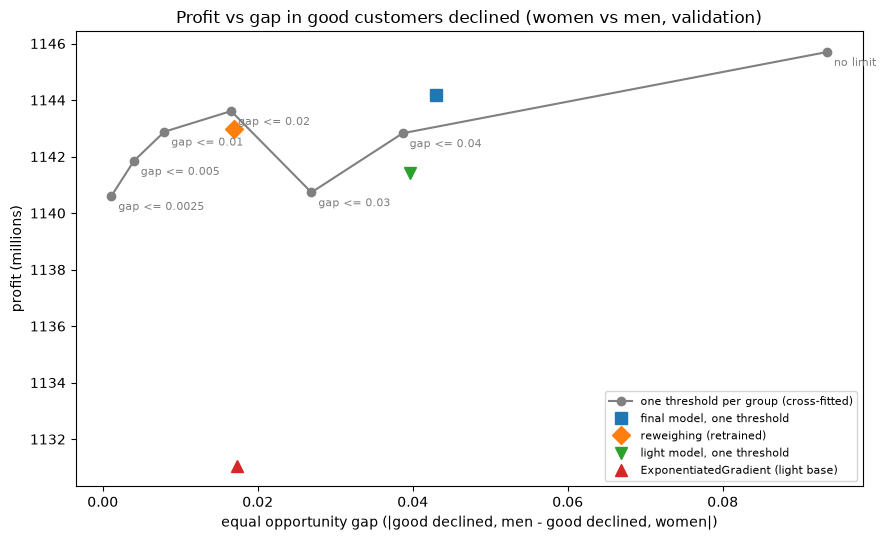

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
curve = mitigation[mitigation.index.str.startswith("group thresholds")]
ax.plot(curve["equal opportunity gap"], curve["profit (millions)"], "o-", color="grey",
        label="one threshold per group (cross-fitted)")
for name, row in curve.iterrows():
    ax.annotate(name.split(", ")[1], (row["equal opportunity gap"], row["profit (millions)"]),
                textcoords="offset points", xytext=(5, -10), fontsize=8, color="grey")
for name, marker in [("final model, one threshold", "s"), ("reweighing (retrained)", "D"),
                     ("light model, one threshold", "v"),
                     ("ExponentiatedGradient (light base)", "^")]:
    row = mitigation.loc[name]
    ax.plot(row["equal opportunity gap"], row["profit (millions)"], marker, ms=9, label=name)
ax.set(title="Profit vs gap in good customers declined (women vs men, validation)",
       xlabel="equal opportunity gap (|good declined, men - good declined, women|)",
       ylabel="profit (millions)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "fig32_fairness_tradeoff.png", dpi=150)
plt.show()

In [10]:
for key, value in facts.items():
    print(f"{key}: {value}")

audit: {('gender', 'F'): {'applicants': 20314.0, 'default rate': 0.0687, 'mean predicted': 0.0736, 'ROC-AUC': 0.7926, 'approval rate': 0.8936, 'good customers declined': 0.0833, 'defaulters declined': 0.4191, 'share approve': 0.4343, 'share refer': 0.4581, 'share decline': 0.1076, 'coverage repay': 0.9157, 'coverage default': 0.8918, 'defaulters auto-approved': 0.1082, 'good customers auto-declined': 0.0843}, ('gender', 'M'): {'applicants': 10437.0, 'default rate': 0.1041, 'mean predicted': 0.0934, 'ROC-AUC': 0.7838, 'approval rate': 0.837, 'good customers declined': 0.1263, 'defaulters declined': 0.4788, 'share approve': 0.3402, 'share refer': 0.4958, 'share decline': 0.1639, 'coverage repay': 0.8728, 'coverage default': 0.9263, 'defaulters auto-approved': 0.0737, 'good customers auto-declined': 0.1272}, ('age band', '<30'): {'applicants': 4475.0, 'default rate': 0.1169, 'mean predicted': 0.1148, 'ROC-AUC': 0.7654, 'approval rate': 0.7781, 'good customers declined': 0.1802, 'defaulter

## Findings

- **Gender, at the money rule:** women are approved 89.4% of the time and men 83.7% (disparate impact ratio 0.94, above the 0.8 line). Good customers are wrongly declined at 8.3% for women vs 12.6% for men: an **equal opportunity gap of 4.3 points against men**. Part of the reason: within gender the model is off in opposite directions (men predicted 9.3% vs 10.4% actual, women 7.4% vs 6.9%; figure 31), but mostly men simply default more often (10.4% vs 6.9%).
- **Age matters more than gender:** approval runs from 77.8% under 30 to 96.3% at 60+ (disparate impact ratio 0.81, just above 0.8), and good customers under 30 are declined 18.0% of the time vs 3.1% at 60+. Age is a model input (it is predictive: 11.7% vs 4.5% default). US Regulation B allows age in an empirically derived score as long as older applicants are not scored down. Here they are favoured, so the risk to watch is the young. ROC-AUC is lowest at 60+ (0.738).
- **The conformal guarantee is per class, not per group:** at α = 10%, 23.0% of defaulters aged 60+ are auto-approved (and 10.8% of women defaulters), while 18.2% of good customers under 30 and 12.7% of good men are auto-declined. The guarantee holds on average over everyone, as promised, but not inside each group. A group-conditional version (one cut-off per class and group) would fix this, but it needs the group when deciding.
- **Proxy test: deleting gender does not hide it.** The other 240 features predict gender with ROC-AUC 0.911, mainly through occupation, employer type and car ownership. But the risk score itself carries little gender (ROC-AUC 0.568 for predicting gender from p), so the gap comes from real differences in default rates more than from the model learning gender.
- **Impossibility, with our own numbers:** the identity FPR = b/(1−b) · (1−PPV)/PPV · (1−FNR) reproduces both groups' rates exactly (0.0833 and 0.1263). If women had men's precision (0.306) and miss rate (0.521), their share of good customers declined would have to be 8.0% vs men's 12.6%. With base rates of 6.9% vs 10.4%, equal error rates and equal precision cannot both hold.
- **Mitigations (all on validation, gender gap in good customers declined):**
  - *Reweighing* cuts the gap from 4.3 to **1.7 points** for 1.2M less profit (−0.1%) and −0.003 ROC-AUC. Gender is used only in training.
  - *ExponentiatedGradient* reaches the same gap (1.7 points) but earns 13M less (−1.1%) than the original model and 10M less than its own light base model. Its decisions are randomised (two models mixed), so two identical applicants can get different answers.
  - *One threshold per group* can close the gap fully (0.1 points at max gap 0.0025, −3.6M), but it needs gender when deciding: men get a *more lenient* threshold (0.1875 vs 0.155 at gap ≤ 0.01). The unconstrained profit-optimal pair goes the other way (men 0.14, women 0.1975) and doubles the gap to 9.4 points for +1.5M. Profit alone pushes towards less fairness.
  - The profit differences are tiny (the whole of figure 32 spans 1.3%), and the cross-fitted sweep is not monotone (gap ≤ 0.02 earns more than ≤ 0.03), so differences of a few million are noise.
- **What reweighing costs:** it keeps the model calibrated overall (8.01% predicted vs 8.07% actual) but widens the within-gender error: men are now predicted 8.6% vs 10.4% actual, women 7.7% vs 6.9%. This is the impossibility in practice: equal opportunity is bought with group calibration.
- **Chosen mitigation: reweighing.** It is deterministic, does not need gender when deciding (using gender in credit decisions is unlawful in many countries, for example under the US Equal Credit Opportunity Act), and closes 60% of the gap at almost no cost. The reweighed model is saved as `models/reweighed_final.joblib`. Step 15 will evaluate **both** models on the test split, as decided here before that split is opened. Step 16 then picks the app model, with the calibration cost above stated in the model card.
- **Human in the loop:** the refer zone (47% of applicants) is where a person reviews the case. For the young and for men, the share referred or declined is higher, so reviewers should see these group rates.